In [5]:
from astropy.io import fits

fname = "DR19seisages_samp_train456789_net10_method14151617_cluster1819_v2.fits"

with fits.open(fname, memmap=True) as hdul:
    cols = hdul["STARFLOW_TABLE"].columns.names
    print(len(cols))
    print(cols)

423
['sdss_id', 'sdss4_apogee_id', 'gaia_dr2_source_id', 'gaia_dr3_source_id', 'tic_v8_id', 'healpix', 'lead', 'version_id', 'catalogid', 'catalogid21', 'catalogid25', 'catalogid31', 'n_associated', 'n_neighborhood', 'sdss5_target_flags', 'sdss4_apogee_target1_flags', 'sdss4_apogee_target2_flags', 'sdss4_apogee2_target1_flags', 'sdss4_apogee2_target2_flags', 'sdss4_apogee2_target3_flags', 'sdss4_apogee_member_flags', 'sdss4_apogee_extra_target_flags', 'ra', 'dec', 'l', 'b', 'plx', 'e_plx', 'pmra', 'e_pmra', 'pmde', 'e_pmde', 'gaia_v_rad', 'gaia_e_v_rad', 'g_mag', 'bp_mag', 'rp_mag', 'j_mag', 'e_j_mag', 'h_mag', 'e_h_mag', 'k_mag', 'e_k_mag', 'ph_qual', 'bl_flg', 'cc_flg', 'w1_mag', 'e_w1_mag', 'w1_flux', 'w1_dflux', 'w1_frac', 'w2_mag', 'e_w2_mag', 'w2_flux', 'w2_dflux', 'w2_frac', 'w1uflags', 'w2uflags', 'w1aflags', 'w2aflags', 'mag4_5', 'd4_5m', 'rms_f4_5', 'sqf_4_5', 'mf4_5', 'csf', 'zgr_teff', 'zgr_e_teff', 'zgr_logg', 'zgr_e_logg', 'zgr_fe_h', 'zgr_e_fe_h', 'zgr_e', 'zgr_e_e', 'zg

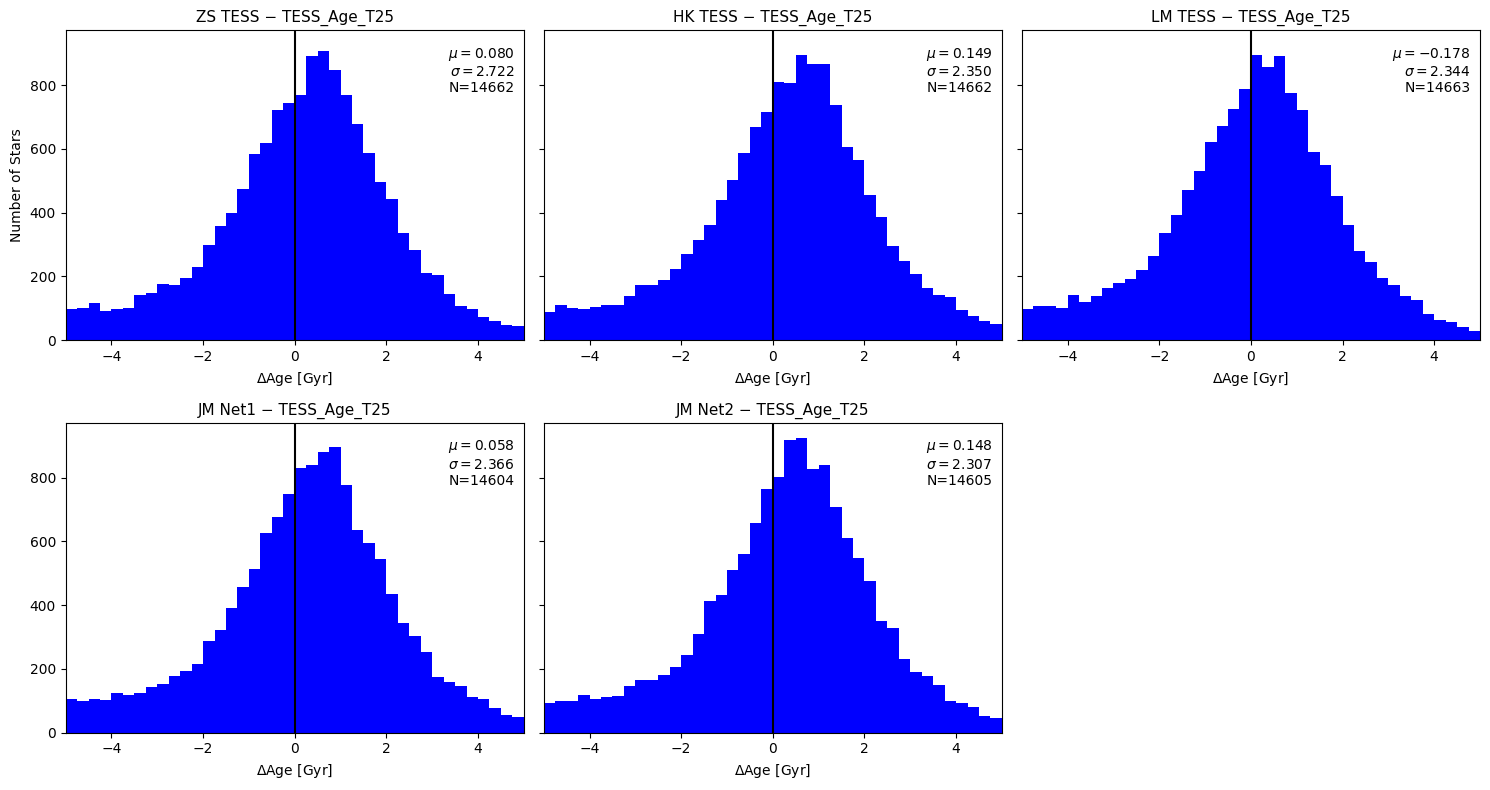

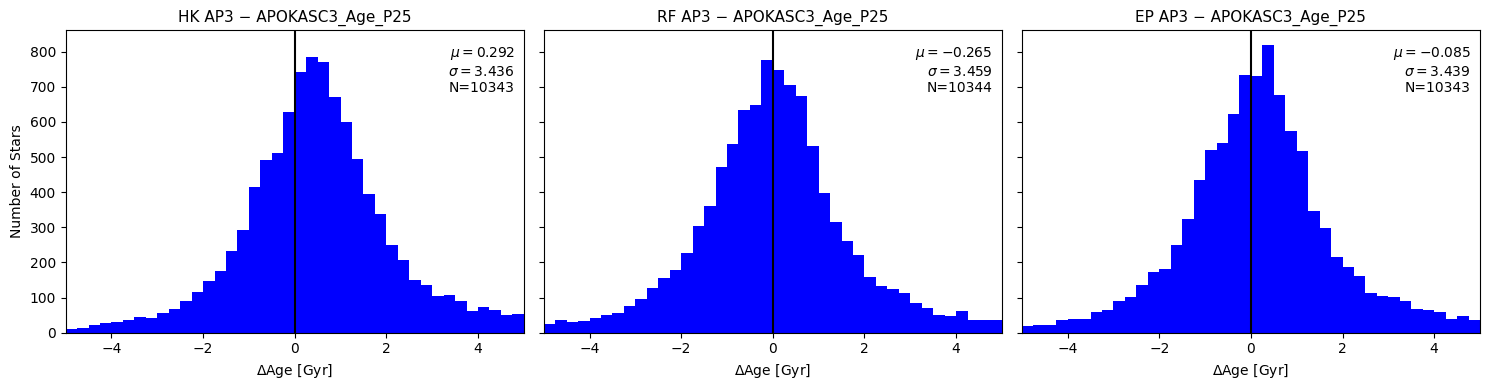

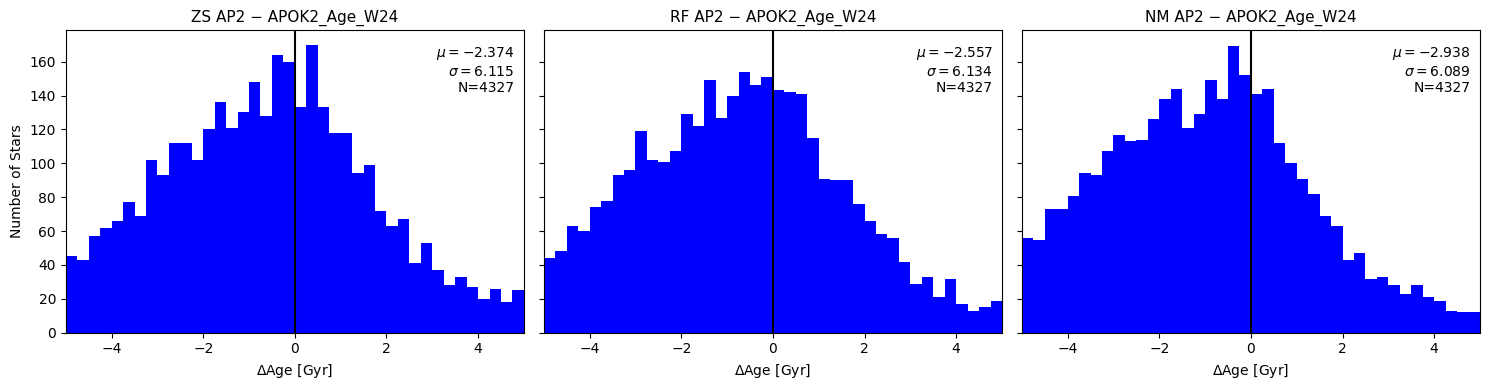

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

with fits.open(fname, memmap=True) as hdul:
    data = hdul["STARFLOW_TABLE"].data

feh_col = "fe_h"
c_col   = "c_h"
n_col   = "n_h"

def get_nontrain_mask(data):
    if "tag" not in data.dtype.names:
        return np.ones(len(data), dtype=bool)

    tags = data["tag"]
    if tags.dtype.kind == "S":
        tags = np.char.decode(tags, "utf-8", errors="ignore")
    tags = np.char.lower(tags.astype(str))

    return ~np.char.startswith(tags, "train")

nontrain = get_nontrain_mask(data)

def make_good(seis_col, nn_col):
    return (
        nontrain &
        np.isfinite(data[seis_col]) & np.isfinite(data[nn_col]) &
        (data[seis_col] > 0) & (data[nn_col] > 0) &
        np.isfinite(data[feh_col]) & (data[feh_col] != -9999) &
        np.isfinite(data[c_col])   & (data[c_col]   != -9999) &
        np.isfinite(data[n_col])   & (data[n_col]   != -9999)
    )

def plot_residual_hists(seis_col, nn_cols, labels, bins=40, xlim=(-5,5), ncols=3):
    nn_cols = [c for c in nn_cols if c in data.dtype.names]
    n = len(nn_cols)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), sharey=True)
    axes = np.atleast_1d(axes).ravel()

    for ax, nn_col in zip(axes, nn_cols):
        m = make_good(seis_col, nn_col)

        d = (data[nn_col][m] - data[seis_col][m]).ravel().astype(float)

        mu = np.mean(d)
        sigma = np.std(d)

        ax.hist(d, bins=bins, range=xlim, color="blue")
        ax.axvline(0.0, color="k", linewidth=1.5)
        ax.set_xlim(xlim)

        ax.set_title(f"{labels.get(nn_col, nn_col)} − {labels.get(seis_col, seis_col)}", fontsize=11)
        ax.set_xlabel(r"$\Delta$Age [Gyr]")

        ax.text(
            0.98, 0.95,
            rf"$\mu={mu:.3f}$" + "\n" + rf"$\sigma={sigma:.3f}$" + f"\nN={len(d)}",
            transform=ax.transAxes, ha="right", va="top", fontsize=10
        )

    for ax in axes[len(nn_cols):]:
        ax.axis("off")

    axes[0].set_ylabel("Number of Stars")
    plt.tight_layout()
    plt.show()

seis_tess = "TESS_Age_T25"
nn_tess = [
    "ZS_TESS_training_Age",
    "HK_TESS_training_Age",
    "LM_TESS_training_Age",
    "JM_TESS_Net1_Age",
    "JM_TESS_Net2_Age",
]

labels = {
    "TESS_Age_T25": "TESS_Age_T25",
    "ZS_TESS_training_Age": "ZS TESS",
    "HK_TESS_training_Age": "HK TESS",
    "LM_TESS_training_Age": "LM TESS",
    "JM_TESS_Net1_Age": "JM Net1",
    "JM_TESS_Net2_Age": "JM Net2",
}

plot_residual_hists(seis_tess, nn_tess, labels, bins=40, xlim=(-5,5), ncols=3)

seis_ap3 = "APOKASC3_Age_P25"
nn_ap3 = [
    "HK_AP3_training_Age",
    "RF_AP3_training_Age",
    "EP_AP3_training_Age",
]
labels.update({
    "APOKASC3_Age_P25": "APOKASC3_Age_P25",
    "HK_AP3_training_Age": "HK AP3",
    "RF_AP3_training_Age": "RF AP3",
    "EP_AP3_training_Age": "EP AP3",
})

plot_residual_hists(seis_ap3, nn_ap3, labels, bins=40, xlim=(-5,5), ncols=3)

seis_ap2 = "APOK2_Age_W24"
nn_ap2 = [
    "ZS_AP2_training_Age",
    "RF_AP2_training_Age",
    "NM_AP2_training_Age",
]
labels.update({
    "APOK2_Age_W24": "APOK2_Age_W24",
    "ZS_AP2_training_Age": "ZS AP2",
    "RF_AP2_training_Age": "RF AP2",
    "NM_AP2_training_Age": "NM AP2",
})

plot_residual_hists(seis_ap2, nn_ap2, labels, bins=40, xlim=(-5,5), ncols=3)

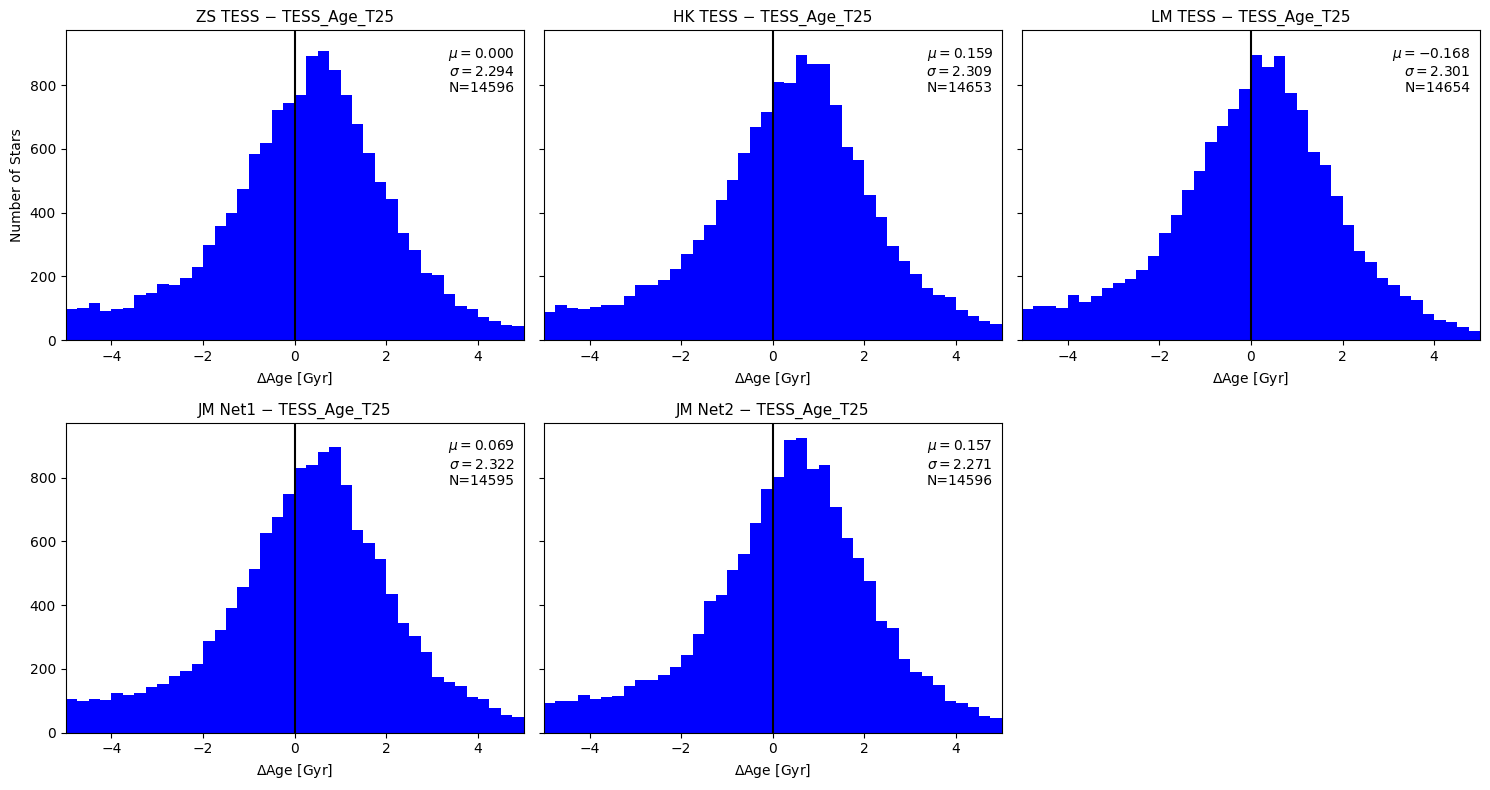

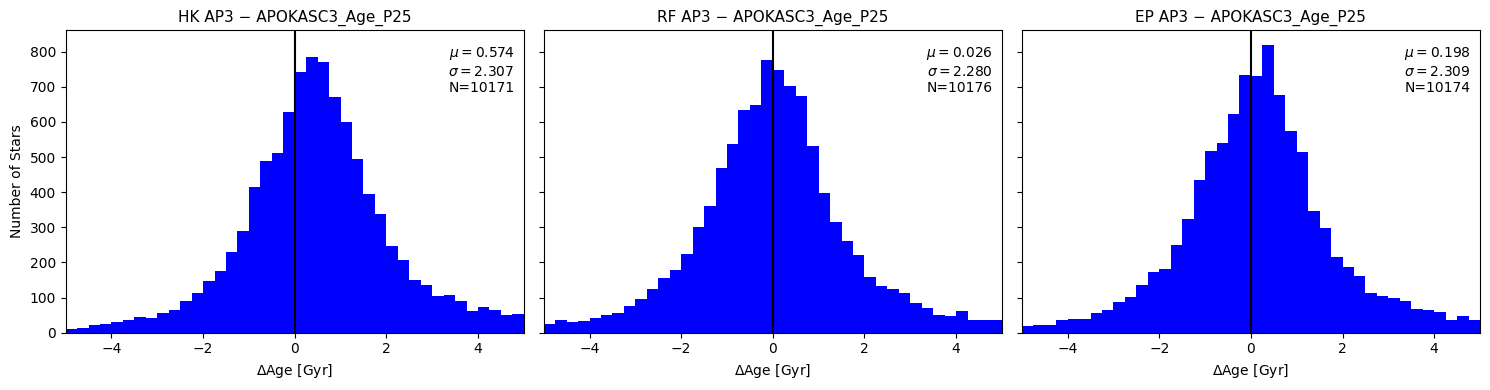

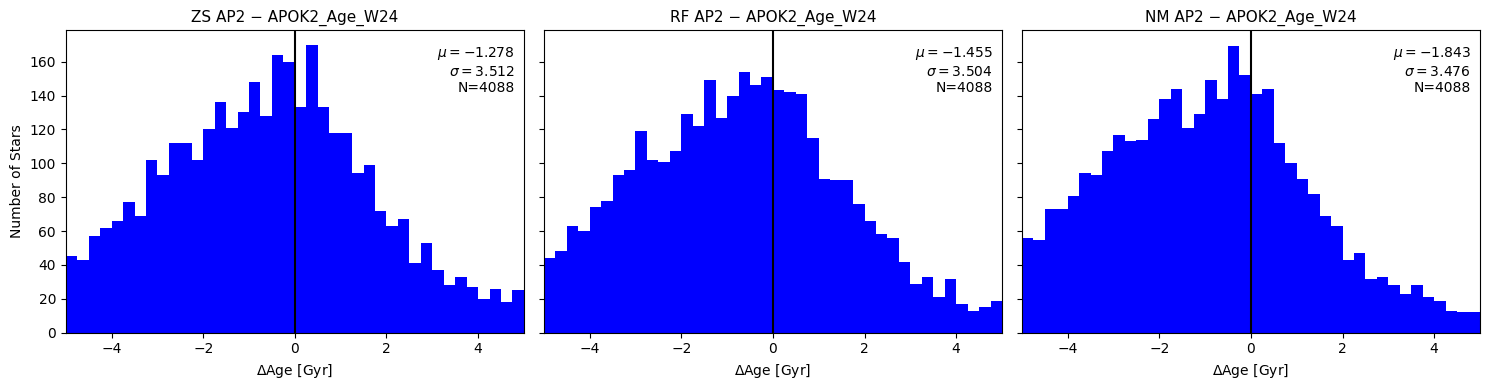

In [7]:
# filtering out ages >= 20Gyr

def make_good(seis_col, nn_col):
    return (
        nontrain &
        np.isfinite(data[seis_col]) & np.isfinite(data[nn_col]) &
        (data[seis_col] > 0) & (data[nn_col] > 0) & (data[seis_col] <= 20) & (data[nn_col] <= 20) &
        np.isfinite(data[feh_col]) & (data[feh_col] != -9999) &
        np.isfinite(data[c_col])   & (data[c_col]   != -9999) &
        np.isfinite(data[n_col])   & (data[n_col]   != -9999)
    )

def plot_residual_hists(seis_col, nn_cols, labels, bins=40, xlim=(-5,5), ncols=3):
    nn_cols = [c for c in nn_cols if c in data.dtype.names]
    n = len(nn_cols)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), sharey=True)
    axes = np.atleast_1d(axes).ravel()

    for ax, nn_col in zip(axes, nn_cols):
        m = make_good(seis_col, nn_col)

        d = (data[nn_col][m] - data[seis_col][m]).ravel().astype(float)

        mu = np.mean(d)
        sigma = np.std(d)

        ax.hist(d, bins=bins, range=xlim, color="blue")
        ax.axvline(0.0, color="k", linewidth=1.5)
        ax.set_xlim(xlim)

        ax.set_title(f"{labels.get(nn_col, nn_col)} − {labels.get(seis_col, seis_col)}", fontsize=11)
        ax.set_xlabel(r"$\Delta$Age [Gyr]")

        ax.text(
            0.98, 0.95,
            rf"$\mu={mu:.3f}$" + "\n" + rf"$\sigma={sigma:.3f}$" + f"\nN={len(d)}",
            transform=ax.transAxes, ha="right", va="top", fontsize=10
        )

    for ax in axes[len(nn_cols):]:
        ax.axis("off")

    axes[0].set_ylabel("Number of Stars")
    plt.tight_layout()
    plt.show()

seis_tess = "TESS_Age_T25"
nn_tess = [
    "ZS_TESS_training_Age",
    "HK_TESS_training_Age",
    "LM_TESS_training_Age",
    "JM_TESS_Net1_Age",
    "JM_TESS_Net2_Age",
]

labels = {
    "TESS_Age_T25": "TESS_Age_T25",
    "ZS_TESS_training_Age": "ZS TESS",
    "HK_TESS_training_Age": "HK TESS",
    "LM_TESS_training_Age": "LM TESS",
    "JM_TESS_Net1_Age": "JM Net1",
    "JM_TESS_Net2_Age": "JM Net2",
}

plot_residual_hists(seis_tess, nn_tess, labels, bins=40, xlim=(-5,5), ncols=3)

seis_ap3 = "APOKASC3_Age_P25"
nn_ap3 = [
    "HK_AP3_training_Age",
    "RF_AP3_training_Age",
    "EP_AP3_training_Age",
]
labels.update({
    "APOKASC3_Age_P25": "APOKASC3_Age_P25",
    "HK_AP3_training_Age": "HK AP3",
    "RF_AP3_training_Age": "RF AP3",
    "EP_AP3_training_Age": "EP AP3",
})

plot_residual_hists(seis_ap3, nn_ap3, labels, bins=40, xlim=(-5,5), ncols=3)

seis_ap2 = "APOK2_Age_W24"
nn_ap2 = [
    "ZS_AP2_training_Age",
    "RF_AP2_training_Age",
    "NM_AP2_training_Age",
]
labels.update({
    "APOK2_Age_W24": "APOK2_Age_W24",
    "ZS_AP2_training_Age": "ZS AP2",
    "RF_AP2_training_Age": "RF AP2",
    "NM_AP2_training_Age": "NM AP2",
})

plot_residual_hists(seis_ap2, nn_ap2, labels, bins=40, xlim=(-5,5), ncols=3)